# XGBoost for King County House Price Prediction

XGBoost stands for **Extreme Gradient Boosting**. It is an ensemble machine learning algorithm based on decision trees.

XGBoost builds trees step by step. Later trees try to correct the errors made by earlier trees. This makes it useful for learning patterns that a single decision tree may miss.

This project is a **regression problem** because the target variable, `price`, is a continuous numerical value. The goal is to predict a house price, not to classify houses into categories.

XGBoost is suitable for house-price prediction because it works well with structured/tabular data and can learn complex, non-linear relationships between house features and price.

This notebook trains, tunes, and evaluates an XGBoost regression model using the final preprocessed datasets produced by the group pipeline.

Notebook flow:

Final preprocessed data -> separate features and target -> baseline XGBoost -> baseline evaluation -> GridSearchCV -> tuned XGBoost -> train/test evaluation -> baseline vs tuned comparison -> overfitting check -> evaluation graphs -> feature importance -> final model.


## 1. Importing Required Libraries

This section imports the libraries and functions needed for the XGBoost model workflow.

- **pandas** is used for loading CSV files, working with datasets, and creating comparison tables.
- **NumPy** is used for numerical calculations, such as calculating RMSE using square root.
- **Matplotlib** is used to create model evaluation graphs.
- **XGBRegressor** is the XGBoost regression model used to predict house prices.
- **GridSearchCV** is used to test different XGBoost hyperparameter combinations and choose the best one using cross-validation.
- **mean_squared_error** is used to calculate MSE.
- **mean_absolute_error** is used to calculate MAE.
- **mean_absolute_percentage_error** is used to calculate MAPE.
- **r2_score** is used to calculate the R² score.


In [ ]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


**Interpretation:**  
All required libraries were imported successfully, so the notebook has the tools needed for loading data, training XGBoost, tuning hyperparameters, calculating metrics, and drawing graphs.


## 2. Uploading the Final Preprocessed Datasets

The datasets used in this notebook are already processed by the group's final preprocessing pipeline.

There is a separate training dataset and a separate testing dataset. Therefore, this notebook does **not** perform preprocessing again and does **not** create another train/test split.

The training data is used to train and tune the XGBoost model. The test data is kept separate and is used to measure performance on unseen data.

The file upload code allows the processed CSV files to be uploaded into Google Colab.


In [ ]:
# ============================================================
# STEP 2: UPLOAD PROCESSED DATASETS
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving final_train_processed_house_data.csv to final_train_processed_house_data (4).csv
Saving final_test_processed_house_data (1).csv to final_test_processed_house_data (1) (4).csv


**Interpretation:**  
The upload output shows that processed training and testing CSV files were uploaded into the Colab session.


### Checking Uploaded File Names

This step prints the CSV files available in the Colab environment. It helps confirm that the required processed training and testing files are present before loading them.


In [ ]:
# ============================================================
# STEP 3: CHECK FILE NAMES
# ============================================================

import os

for file in os.listdir():
    if file.endswith(".csv"):
        print(file)

final_train_processed_house_data (3).csv
final_train_processed_house_data (2).csv
final_test_processed_house_data (1).csv
final_test_processed_house_data (1) (2).csv
final_test_processed_house_data (1) (1).csv
final_train_processed_house_data.csv
final_train_processed_house_data (4).csv
final_test_processed_house_data (1) (4).csv
final_train_processed_house_data (1).csv
final_test_processed_house_data (1) (3).csv


**Interpretation:**  
The output lists multiple uploaded CSV files, including processed training and testing files. The next step loads the specific file names used by this notebook.


## 3. Loading the Final Processed Training and Testing Data

`pd.read_csv()` loads the final processed CSV files.

- `train_df` contains the processed training data.
- `test_df` contains the processed testing data.

Both datasets should contain the same input feature structure and the target variable `price`.


In [ ]:
# ============================================================
# STEP 4: LOAD DATASETS
# ============================================================

train_df = pd.read_csv(
    "final_train_processed_house_data (1).csv"
)

test_df = pd.read_csv(
    "final_test_processed_house_data (1) (1).csv"
)

print("Training dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)

print("\nFirst 5 rows of training data:")
display(train_df.head())

Training dataset shape: (17290, 93)
Test dataset shape: (4323, 93)

First 5 rows of training data:


,bedrooms,bathrooms,floors,waterfront,view,condition,grade,sqft_basement,yr_built,lat,...,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199,price
0,-0.395263,-0.474451,-0.919600,0,0,4,9,-0.656310,0.404001,-1.396608,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,325000.0
1,-1.468964,-1.452583,-0.919600,0,0,3,6,-0.200433,-1.430565,-0.060172,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,257000.0
2,-0.395263,-1.452583,0.001545,0,0,3,6,-0.451165,-0.988910,-0.552847,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,228500.0
3,-0.395263,0.177636,-0.919600,0,0,4,7,1.189993,0.200160,-1.193614,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,288000.0
4,-1.468964,0.503680,0.922690,0,0,3,8,0.016109,1.219364,1.040039,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,479000.0


**Interpretation:**  
The training dataset contains **17,290 rows** and **93 columns**. The testing dataset contains **4,323 rows** and **93 columns**. The first five training rows show that the data is already processed, with scaled numeric columns and encoded zipcode columns. The `price` column is still included as the prediction target.


## 4. Understanding and Validating the Processed Data

This section checks whether the processed training and testing datasets are suitable for model training.

We check:

- training shape and testing shape, to know the number of rows and columns.
- number of columns, to confirm both datasets have the same structure.
- whether the target column `price` exists in both datasets.
- missing values, because missing values can cause model errors or unreliable training.

This notebook does not describe preprocessing as being performed here, because the preprocessing was already completed by the group pipeline.


In [ ]:
# ============================================================
# STEP 5: CHECK DATASETS
# ============================================================

print("Training Shape:", train_df.shape)
print("Testing Shape :", test_df.shape)

print("\nNumber of training columns:", len(train_df.columns))
print("Number of testing columns :", len(test_df.columns))

print("\nTarget 'price' in training:",
      "price" in train_df.columns)

print("Target 'price' in testing:",
      "price" in test_df.columns)

print("\nMissing values in training:",
      train_df.isnull().sum().sum())

print("Missing values in testing:",
      test_df.isnull().sum().sum())

Training Shape: (17290, 93)
Testing Shape : (4323, 93)

Number of training columns: 93
Number of testing columns : 93

Target 'price' in training: True
Target 'price' in testing: True

Missing values in training: 0
Missing values in testing: 0


### Dataset Check - Interpretation

The training data has **17,290 rows** and **93 columns**. The testing data has **4,323 rows** and **93 columns**.

Both datasets have **93 columns**, and the target column `price` is present in both training and testing data.

The missing-value check shows **0 missing values** in the training data and **0 missing values** in the testing data. This means the model will not face missing-data problems from these processed datasets.


## 5. Separating Input Features and Target

The target variable is `price`, because this is the house price that the model must predict.

- `X_train` contains the input features from the training dataset.
- `y_train` contains the training target values, which are the training house prices.
- `X_test` contains the input features from the testing dataset.
- `y_test` contains the actual house prices from the testing dataset.

The `price` column must be removed from `X` because it is the answer the model is trying to predict. The model learns the relationship:

input house features -> house price

Another `train_test_split` is not needed because the group pipeline has already provided separate final training and testing datasets.


In [ ]:
# ============================================================
# STEP 6: SEPARATE FEATURES AND TARGET
# ============================================================

X_train = train_df.drop(columns=["price"])
y_train = train_df["price"]

X_test = test_df.drop(columns=["price"])
y_test = test_df["price"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

X_train shape: (17290, 92)
y_train shape: (17290,)
X_test shape : (4323, 92)
y_test shape : (4323,)


**Interpretation:**  
After separating the target, `X_train` has **17,290 rows** and **92 input features**, while `X_test` has **4,323 rows** and **92 input features**. The target arrays contain **17,290** training prices and **4,323** testing prices.


## 6. Final Data Validation Before Model Training

Before training XGBoost, this section performs final validation checks on the feature datasets.

The code checks:

- missing values in `X_train`.
- missing values in `X_test`.
- whether any non-numeric columns are present.
- whether the train and test feature columns are identical.
- the number of input features.

These checks are important because XGBoost needs consistent numeric feature columns in both training and testing data.


In [ ]:
# ============================================================
# STEP 7: FINAL VALIDATION
# ============================================================

print("Missing values in X_train:",
      X_train.isnull().sum().sum())

print("Missing values in X_test:",
      X_test.isnull().sum().sum())

non_numeric_train = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("\nNon-numeric columns:")
print(non_numeric_train)

print("\nTrain/Test columns identical:",
      X_train.columns.equals(X_test.columns))

print("\nNumber of input features:",
      X_train.shape[1])

Missing values in X_train: 0
Missing values in X_test: 0

Non-numeric columns:
[]

Train/Test columns identical: True

Number of input features: 92


### Validation Interpretation

The output shows **0 missing values** in `X_train` and **0 missing values** in `X_test`.

There are **no non-numeric columns**, so the processed features are suitable for XGBoost.

The train and test feature columns are identical, which is important because the model must receive the same feature structure during training and testing.

The model uses **92 input features**.


## 7. Baseline XGBoost Model

A baseline model gives an initial performance result before hyperparameter tuning. It helps us understand what the model can achieve with a simple starting configuration.

`XGBRegressor` is the regression version of XGBoost. It predicts continuous numeric values, so it is suitable for predicting house prices.

XGBoost is based on boosted decision trees. A decision tree splits the data using feature values. Boosting means several trees are built sequentially, and later trees try to reduce the errors made by earlier trees.

Important parameters used in the baseline model:

- `objective="reg:squarederror"` tells XGBoost that this is a regression task using squared error.
- `random_state=42` makes the result reproducible.
- `n_jobs=-1` allows the model to use all available CPU cores.

The `.fit(X_train, y_train)` function trains the model. It learns patterns between the processed house features and prices using only the training dataset.


In [ ]:
# ============================================================
# STEP 8: BASELINE XGBOOST MODEL
# ============================================================

baseline_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)

print("Baseline XGBoost training completed!")

Baseline XGBoost training completed!


**Interpretation:**  
The baseline XGBoost model was trained successfully. This gives a starting point for comparison before tuning.


## 8. Making Baseline Predictions

`baseline_model.predict(X_test)` uses the trained baseline model to predict house prices for the unseen test data.

Predictions are made on `X_test` for baseline evaluation because the test data was not used to train the model. This gives a fairer estimate of how the model performs on new data.


In [ ]:
# ============================================================
# STEP 9: BASELINE PREDICTIONS
# ============================================================

baseline_pred = baseline_model.predict(X_test)

print("Baseline predictions completed!")

print("\nFirst 5 predicted prices:")
print(baseline_pred[:5])

Baseline predictions completed!

First 5 predicted prices:
[ 376770.47  951807.8  1145025.1  2056571.1   714510.9 ]


**Interpretation:**  
The baseline model produced predictions for the test data. The first five predicted prices are displayed as a quick check that prediction worked.


## 9. Evaluating the Baseline XGBoost Model

This section evaluates the baseline model using the metrics calculated in the code.

### MSE - Mean Squared Error
MSE measures the average squared prediction error. Large errors receive a bigger penalty. Lower is better.

### RMSE - Root Mean Squared Error
RMSE is the square root of MSE. It gives the prediction error in the same general unit as the target price. Lower is better.

### MAE - Mean Absolute Error
MAE measures the average absolute difference between actual and predicted values. Lower is better.

### MAPE - Mean Absolute Percentage Error
MAPE shows the average prediction error as a percentage. Lower is better.

### R² Score
R² shows how much variation in house prices is explained by the model. A value closer to 1 generally indicates better predictive fit.


In [ ]:
# ============================================================
# STEP 10: BASELINE MODEL EVALUATION
# ============================================================

baseline_mse = mean_squared_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(baseline_mse)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_mape = mean_absolute_percentage_error(
    y_test,
    baseline_pred
) * 100

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("========== BASELINE XGBOOST RESULTS ==========")

print(f"MSE  : {baseline_mse:,.2f}")
print(f"RMSE : {baseline_rmse:,.2f}")
print(f"MAE  : {baseline_mae:,.2f}")
print(f"MAPE : {baseline_mape:.2f}%")
print(f"R²   : {baseline_r2:.4f}")

========== BASELINE XGBOOST RESULTS ==========
MSE  : 20,513,451,416.49
RMSE : 143,225.18
MAE  : 69,435.79
MAPE : 12.49%
R²   : 0.8643


### Baseline Model - Result Interpretation

The baseline model achieved:

- MSE: **20,513,451,416.49**
- RMSE: **143,225.18**
- MAE: **69,435.79**
- MAPE: **12.49%**
- R²: **0.8643**

This means the baseline model explains a large portion of the variation in house prices, but the error values show that there is still room for improvement through hyperparameter tuning.


## 10. Hyperparameter Tuning with GridSearchCV

Hyperparameters are settings that control how XGBoost learns. The baseline model uses one configuration, but different parameter values can change model performance.

### GridSearchCV

`GridSearchCV` systematically tests every combination defined in `param_grid`. It uses cross-validation to compare combinations and chooses the best-performing combination according to the configured scoring metric.

The parameter grid in this notebook tests **32 combinations**:

- `n_estimators`: **300, 500**. This controls the number of boosting trees. More trees can improve learning but may increase training time and overfitting risk.
- `max_depth`: **4, 6**. This controls how deep each tree can grow. Deeper trees can learn more complex patterns but may overfit.
- `learning_rate`: **0.03, 0.05**. This controls how strongly each tree contributes. Smaller values usually learn more slowly.
- `subsample`: **0.8, 1.0**. This controls the fraction of training rows used for each tree. Lower values can reduce overfitting.
- `colsample_bytree`: **0.8, 1.0**. This controls the fraction of features used for each tree. Lower values can make the model less dependent on all features.

### Cross-Validation

The actual `cv` value is **3**, so this notebook uses **3-fold cross-validation**.

In 3-fold cross-validation, the training data is divided into 3 parts. The model trains using 2 parts and validates using the remaining part. This repeats so different parts are used for validation.

This gives a more reliable way to compare parameter combinations than using only one validation split.

Other `GridSearchCV` settings:

- `scoring="neg_root_mean_squared_error"` means the best model is selected based on RMSE. Scikit-learn uses a negative value internally because it expects higher scores to be better.
- `n_jobs=-1` uses all available CPU cores.
- `verbose=2` prints progress while grid search is running.


In [ ]:
# ============================================================
# STEP 11: DEFINE MODEL FOR HYPERPARAMETER TUNING
# ============================================================

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_grid = {

    "n_estimators": [300, 500],

    "max_depth": [4, 6],

    "learning_rate": [0.03, 0.05],

    "subsample": [0.8, 1.0],

    "colsample_bytree": [0.8, 1.0]
}

print("Hyperparameter grid created successfully!")

Hyperparameter grid created successfully!


**Interpretation:**  
The XGBoost model for tuning and the parameter grid were created successfully. This prepares the notebook for systematic hyperparameter testing.


In [ ]:
# ============================================================
# STEP 12: SET UP GRID SEARCH
# ============================================================

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,

    scoring="neg_root_mean_squared_error",

    cv=3,

    n_jobs=-1,

    verbose=2
)

print("GridSearchCV created successfully!")

GridSearchCV created successfully!


**Interpretation:**  
`GridSearchCV` was created using the XGBoost estimator, the defined parameter grid, 3-fold cross-validation, and RMSE-based scoring.


### Running Grid Search

`grid_search.fit(X_train, y_train)` is the computationally expensive step. It trains and validates several XGBoost configurations using the training data.

Because the grid contains 32 candidates and `cv=3`, the output shows **96 fits** in total.


In [ ]:
# ============================================================
# STEP 13: HYPERPARAMETER TUNING
# ============================================================

grid_search.fit(
    X_train,
    y_train
)

print("\nHyperparameter tuning completed!")

Fitting 3 folds for each of 32 candidates, totalling 96 fits

Hyperparameter tuning completed!


**Interpretation:**  
Hyperparameter tuning completed successfully. GridSearchCV tested the defined XGBoost configurations using 3-fold cross-validation.


## 11. Best Hyperparameters Found

After GridSearchCV finishes, `best_params_` gives the parameter combination that achieved the best cross-validation result according to the configured RMSE scoring method.

The notebook also prints the best cross-validation RMSE.


In [ ]:
# ============================================================
# STEP 14: BEST HYPERPARAMETERS
# ============================================================

print("Best Hyperparameters:")

for parameter, value in grid_search.best_params_.items():
    print(parameter, ":", value)

print(
    "\nBest Cross-Validation RMSE:",
    -grid_search.best_score_
)

Best Hyperparameters:
colsample_bytree : 1.0
learning_rate : 0.05
max_depth : 6
n_estimators : 500
subsample : 0.8

Best Cross-Validation RMSE: 113678.80551068745


### Best Parameter Interpretation

The best hyperparameters found were:

- `colsample_bytree`: **1.0**
- `learning_rate`: **0.05**
- `max_depth`: **6**
- `n_estimators`: **500**
- `subsample`: **0.8**

The best cross-validation RMSE was **113,678.81**. Since the grid search used RMSE-based scoring, this was the best configuration among the tested parameter combinations.


## 12. Tuned XGBoost Model

`grid_search.best_estimator_` returns the XGBoost model using the best hyperparameters found during GridSearchCV.

This becomes the tuned XGBoost candidate model.


In [ ]:
# ============================================================
# STEP 15: GET BEST XGBOOST MODEL
# ============================================================

best_model = grid_search.best_estimator_

print("Final tuned XGBoost model:")
print(best_model)

Final tuned XGBoost model:
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)


**Interpretation:**  
The tuned XGBoost model uses the selected hyperparameters from GridSearchCV. This model is then used for final training and testing predictions.


### Training and Testing Predictions

Predictions are made for both `X_train` and `X_test`.

- Training predictions help us understand how well the tuned model learned the training data.
- Testing predictions show how well the tuned model performs on unseen data.

Comparing training and testing performance helps identify possible overfitting.


In [ ]:
# ============================================================
# STEP 16: FINAL PREDICTIONS
# ============================================================

y_train_pred = best_model.predict(X_train)

y_test_pred = best_model.predict(X_test)

print("Training predictions completed!")
print("Testing predictions completed!")

Training predictions completed!
Testing predictions completed!


**Interpretation:**  
The tuned model produced predictions for both the training data and the unseen testing data.


## 13. Reusable Model Evaluation Function

Instead of writing the same metric calculations repeatedly, the `evaluate_model()` function calculates all required evaluation metrics in one place.

The function returns:

- MSE
- RMSE
- MAE
- MAPE
- R²

Using the same evaluation function for training and testing makes the comparison fair and consistent.


In [ ]:
# ============================================================
# STEP 17: EVALUATION FUNCTION
# ============================================================

def evaluate_model(y_true, y_pred):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mse, rmse, mae, mape, r2

print("Evaluation function created!")

Evaluation function created!


**Interpretation:**  
The reusable evaluation function was created successfully.


## 14. Tuned Model Performance

The tuned XGBoost model is evaluated separately on:

1. Training data
2. Testing data

Training performance shows how well the model learned the training dataset. Testing performance shows how well it generalizes to unseen data.


In [ ]:
# ============================================================
# STEP 18: TRAINING METRICS
# ============================================================

(
    train_mse,
    train_rmse,
    train_mae,
    train_mape,
    train_r2

) = evaluate_model(
    y_train,
    y_train_pred
)

print("Training metrics calculated!")

Training metrics calculated!


In [ ]:
# ============================================================
# STEP 19: TESTING METRICS
# ============================================================

(
    test_mse,
    test_rmse,
    test_mae,
    test_mape,
    test_r2

) = evaluate_model(
    y_test,
    y_test_pred
)

print("Testing metrics calculated!")

Testing metrics calculated!


In [ ]:
# ============================================================
# STEP 20: FINAL MODEL PERFORMANCE
# ============================================================

print("========== TRAINING PERFORMANCE ==========")

print(f"MSE  : {train_mse:,.2f}")
print(f"RMSE : {train_rmse:,.2f}")
print(f"MAE  : {train_mae:,.2f}")
print(f"MAPE : {train_mape:.2f}%")
print(f"R²   : {train_r2:.4f}")


print("\n========== TESTING PERFORMANCE ==========")

print(f"MSE  : {test_mse:,.2f}")
print(f"RMSE : {test_rmse:,.2f}")
print(f"MAE  : {test_mae:,.2f}")
print(f"MAPE : {test_mape:.2f}%")
print(f"R²   : {test_r2:.4f}")

========== TRAINING PERFORMANCE ==========
MSE  : 3,183,437,943.06
RMSE : 56,421.96
MAE  : 40,363.27
MAPE : 9.00%
R²   : 0.9756

========== TESTING PERFORMANCE ==========
MSE  : 19,344,362,177.92
RMSE : 139,084.01
MAE  : 65,831.08
MAPE : 11.94%
R²   : 0.8720


### Tuned Model Performance - Interpretation

The tuned model training results are:

- Training MSE: **3,183,437,943.06**
- Training RMSE: **56,421.96**
- Training MAE: **40,363.27**
- Training MAPE: **9.00%**
- Training R²: **0.9756**

The tuned model testing results are:

- Testing MSE: **19,344,362,177.92**
- Testing RMSE: **139,084.01**
- Testing MAE: **65,831.08**
- Testing MAPE: **11.94%**
- Testing R²: **0.8720**

The model performs better on training data than on testing data. This is expected to some extent, but the gap should be checked carefully in the overfitting section.


## 15. Training vs Testing Performance Comparison

This table makes it easier to compare the tuned model's training and testing performance across the evaluation metrics.

A small difference can suggest better generalization. A very large difference, especially when training performance is much better, can indicate overfitting.


In [ ]:
# ============================================================
# STEP 21: TRAIN VS TEST PERFORMANCE TABLE
# ============================================================

performance_df = pd.DataFrame({

    "Metric": [
        "MSE",
        "RMSE",
        "MAE",
        "MAPE (%)",
        "R²"
    ],

    "Training": [
        train_mse,
        train_rmse,
        train_mae,
        train_mape,
        train_r2
    ],

    "Testing": [
        test_mse,
        test_rmse,
        test_mae,
        test_mape,
        test_r2
    ]
})

display(performance_df)

,Metric,Training,Testing
0,MSE,3.183438e+09,1.934436e+10
1,RMSE,5.642196e+04,1.390840e+05
2,MAE,4.036327e+04,6.583108e+04
3,MAPE (%),8.996518e+00,1.194090e+01
4,R²,9.756336e-01,8.720414e-01


### Interpretation

The table shows that the tuned model has stronger training performance than testing performance.

Training RMSE is **56,421.96**, while testing RMSE is **139,084.01**. Training MAPE is **9.00%**, while testing MAPE is **11.94%**. Training R² is **0.9756**, while testing R² is **0.8720**.

This shows a clear train/test gap, so the model should be checked for generalization and possible overfitting.


## 16. Baseline vs Tuned XGBoost Comparison

The purpose of hyperparameter tuning is not simply to create a different model. We must check whether tuning actually improves performance.

The baseline and tuned models are compared using the same unseen test dataset and the same evaluation metrics.


In [ ]:
# ============================================================
# STEP 22: BASELINE VS TUNED XGBOOST
# ============================================================

comparison_df = pd.DataFrame({

    "Model": [
        "Baseline XGBoost",
        "Tuned XGBoost"
    ],

    "MSE": [
        baseline_mse,
        test_mse
    ],

    "RMSE": [
        baseline_rmse,
        test_rmse
    ],

    "MAE": [
        baseline_mae,
        test_mae
    ],

    "MAPE (%)": [
        baseline_mape,
        test_mape
    ],

    "R²": [
        baseline_r2,
        test_r2
    ]
})

display(comparison_df)

,Model,MSE,RMSE,MAE,MAPE (%),R²
0,Baseline XGBoost,2.051345e+10,143225.177314,69435.789176,12.493723,0.864308
1,Tuned XGBoost,1.934436e+10,139084.011223,65831.081318,11.940905,0.872041


### Baseline vs Tuned - Interpretation

The tuned XGBoost model performs better than the baseline model on all listed test metrics.

- MSE is lower for tuned XGBoost: **19,344,362,177.92** vs **20,513,451,416.49**.
- RMSE is lower for tuned XGBoost: **139,084.01** vs **143,225.18**.
- MAE is lower for tuned XGBoost: **65,831.08** vs **69,435.79**.
- MAPE is lower for tuned XGBoost: **11.94%** vs **12.49%**.
- R² is higher for tuned XGBoost: **0.8720** vs **0.8643**.

Based on these test results, the tuned model improves over the baseline model.


## 17. Overfitting and Generalization Check

Overfitting occurs when a model performs extremely well on training data but performs noticeably worse on unseen testing data.

The existing code compares:

- training RMSE vs testing RMSE
- training MAPE vs testing MAPE
- training R² vs testing R²

These comparisons help judge whether the tuned model generalizes well.


In [ ]:
# ============================================================
# STEP 23: OVERFITTING CHECK
# ============================================================

print("========== OVERFITTING CHECK ==========")

print(
    f"Training RMSE : {train_rmse:,.2f}"
)
print(
    f"Testing RMSE  : {test_rmse:,.2f}"
)

print()

print(
    f"Training MAPE : {train_mape:.2f}%"
)
print(
    f"Testing MAPE  : {test_mape:.2f}%"
)

print()

print(
    f"Training R²   : {train_r2:.4f}"
)
print(
    f"Testing R²    : {test_r2:.4f}"
)

========== OVERFITTING CHECK ==========
Training RMSE : 56,421.96
Testing RMSE  : 139,084.01

Training MAPE : 9.00%
Testing MAPE  : 11.94%

Training R²   : 0.9756
Testing R²    : 0.8720


### Overfitting Check - Interpretation

The tuned model has:

- Training RMSE: **56,421.96**
- Testing RMSE: **139,084.01**
- Training MAPE: **9.00%**
- Testing MAPE: **11.94%**
- Training R²: **0.9756**
- Testing R²: **0.8720**

There is a noticeable train/test gap, especially in RMSE and R². This suggests **some overfitting concern**, because the model performs much better on training data than on unseen testing data. However, the testing R² of **0.8720** still shows that the model has useful predictive performance on the test set.


## 18. Actual vs Predicted House Prices

This table compares individual house prices from the test set.

It contains:

- actual house price
- predicted house price
- absolute error
- percentage error

Looking at individual predictions is useful because it shows examples where the model predicts closely and examples where the prediction error is larger.


In [ ]:
# ============================================================
# STEP 24: ACTUAL VS PREDICTED PRICES
# ============================================================

results_df = pd.DataFrame({

    "Actual Price":
        y_test.values,

    "Predicted Price":
        y_test_pred,

    "Absolute Error":
        np.abs(
            y_test.values - y_test_pred
        ),

    "Percentage Error":
        (
            np.abs(
                y_test.values - y_test_pred
            )
            /
            np.abs(y_test.values)
        ) * 100
})

display(results_df.head(20))

,Actual Price,Predicted Price,Absolute Error,Percentage Error
0,365000.0,3.876914e+05,22691.375000,6.216815
1,865000.0,8.621321e+05,2867.937500,0.331553
2,1038000.0,1.116347e+06,78346.625000,7.547844
3,1490000.0,1.871592e+06,381591.875000,25.610193
4,711000.0,7.079354e+05,3064.562500,0.431021
5,211000.0,2.402819e+05,29281.859375,13.877658
6,790000.0,7.748223e+05,15177.687500,1.921226
7,680000.0,6.549130e+05,25087.000000,3.689265
8,384500.0,4.554119e+05,70911.875000,18.442620
9,605000.0,5.938196e+05,11180.437500,1.848006


**Interpretation:**  
The first 20 rows show that some predictions are very close to the actual prices, while others have larger percentage errors. For example, some rows have very small percentage errors, while row 12 has a larger error of about **39.44%**. This helps show that model performance can vary from house to house.


### Actual vs Predicted Price Plot

Each point represents a house in the test dataset.

The x-axis shows the actual price, and the y-axis shows the XGBoost predicted price. Points closer to the diagonal line indicate more accurate predictions.


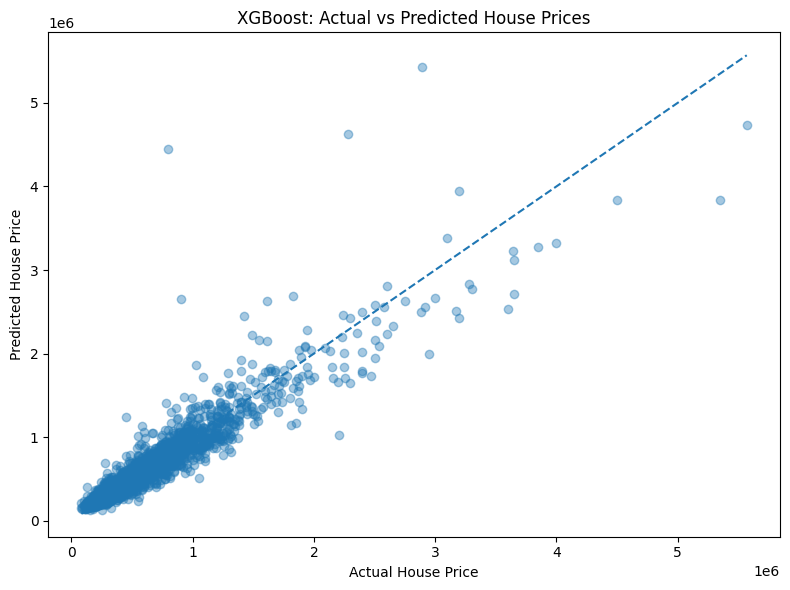

In [ ]:
# ============================================================
# STEP 25: ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.4
)

minimum = min(
    y_test.min(),
    y_test_pred.min()
)

maximum = max(
    y_test.max(),
    y_test_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.title(
    "XGBoost: Actual vs Predicted House Prices"
)

plt.tight_layout()

plt.show()

### Graph Interpretation

The points generally follow the diagonal direction, which means the model captures the overall relationship between actual and predicted prices. There is still visible spread around the line, especially for higher-priced houses, so the predictions are not perfect.


## 19. Residual Analysis

A residual is calculated as:

`Residual = Actual Price - Predicted Price`

- A residual close to 0 means a smaller prediction error.
- A positive residual means the actual price is higher than the prediction.
- A negative residual means the predicted price is higher than the actual price.


In [ ]:
# ============================================================
# STEP 26: CALCULATE RESIDUALS
# ============================================================

residuals = (
    y_test.values - y_test_pred
)

print("First 10 residuals:")

print(residuals[:10])

First 10 residuals:
[ -22691.375       2867.9375    -78346.625    -381591.875
    3064.5625    -29281.859375   15177.6875     25087.
  -70911.875      11180.4375  ]


**Interpretation:**  
The first 10 residuals show both positive and negative values. This means the model sometimes under-predicts and sometimes over-predicts house prices.


### Residual Plot

A good residual plot generally has points distributed around zero without a strong systematic pattern. Large residuals show larger prediction errors.


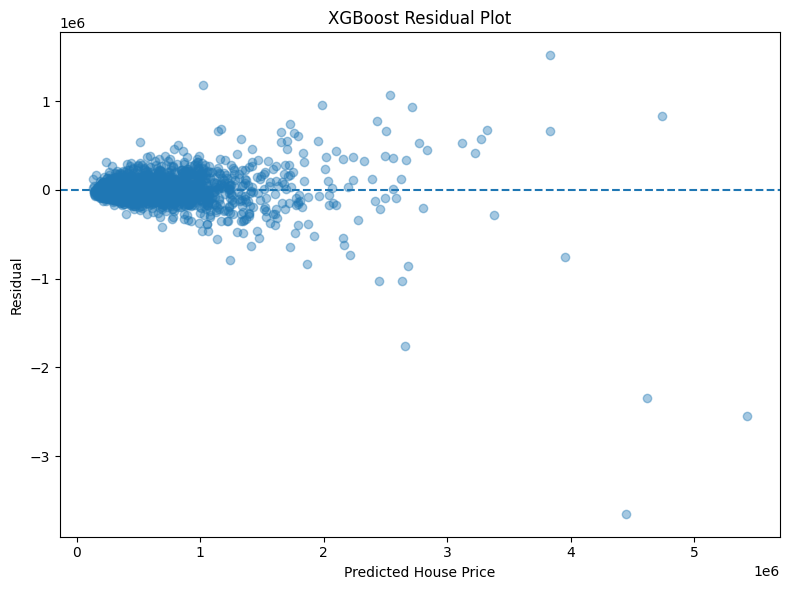

In [ ]:
# ============================================================
# STEP 27: RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residual")

plt.title(
    "XGBoost Residual Plot"
)

plt.tight_layout()

plt.show()

### Residual Plot Interpretation

The residual plot shows many points around zero, but there are also larger residuals. The spread appears wider for some higher predicted prices, which suggests the model has larger errors for some expensive or unusual houses.


## 20. XGBoost Feature Importance

Feature importance shows which processed input features contributed more strongly to the XGBoost model's decisions.

The importance scores are obtained from the trained XGBoost model. Sorting the features helps identify which features were most influential. Only the top features are graphed so the chart remains readable.

Feature importance shows model influence/usage. It does **not** prove that a feature directly causes house prices to change.


In [ ]:
# ============================================================
# STEP 28: FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    "Feature":
        X_train.columns,

    "Importance":
        best_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print("Top 15 important features:")

display(
    feature_importance.head(15)
)

Top 15 important features:


,Feature,Importance
6,grade,0.246839
18,sqft_living_log,0.112322
3,waterfront,0.110119
25,zipcode_98004,0.055161
9,lat,0.045514
46,zipcode_98039,0.043459
14,house_age,0.036436
70,zipcode_98112,0.024743
10,long,0.024412
4,view,0.023896


### Feature Importance Interpretation

The most important features in the tuned XGBoost model are `grade`, `sqft_living_log`, `waterfront`, `zipcode_98004`, and `lat`.

This suggests that house quality, living area, waterfront status, and location-related features played a major role in the model's predictions. However, this does not prove direct causation.


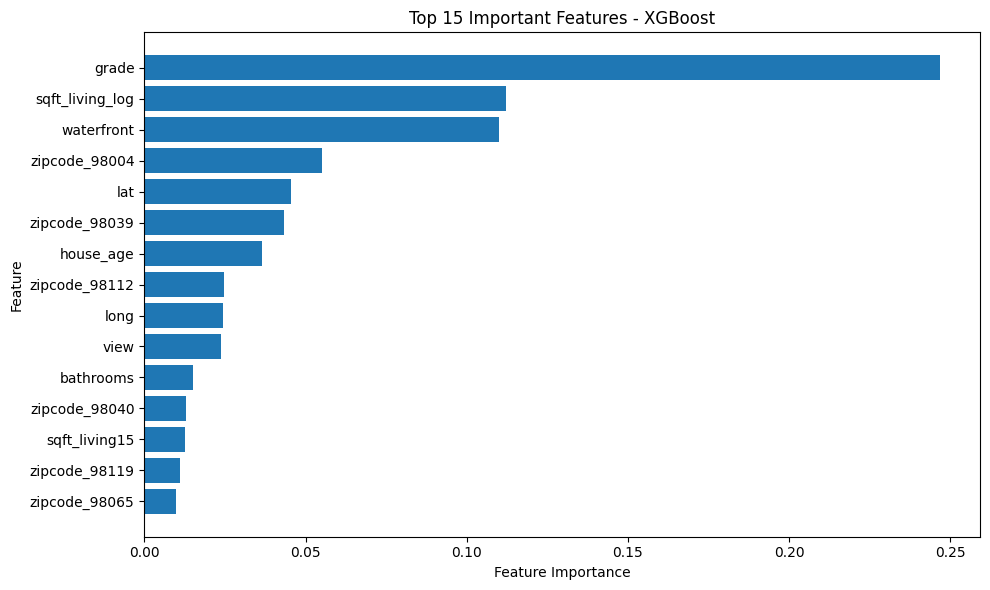

In [ ]:
# ============================================================
# STEP 29: FEATURE IMPORTANCE GRAPH
# ============================================================

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Important Features - XGBoost"
)

plt.tight_layout()

plt.show()

**Interpretation:**  
The bar chart visualizes the top 15 important features. `grade` has the highest importance, followed by `sqft_living_log` and `waterfront`.


## 21. Saving Model Outputs

### Saving Predictions

The predictions are saved to CSV for later analysis and reporting.


In [ ]:
# ============================================================
# STEP 30: SAVE PREDICTIONS
# ============================================================

results_df.to_csv(
    "xgboost_predictions.csv",
    index=False
)

print(
    "Predictions saved as xgboost_predictions.csv"
)

Predictions saved as xgboost_predictions.csv


### Saving Feature Importance

Feature importance is saved so the important predictors can be reviewed later without rerunning the entire model.


In [ ]:
# ============================================================
# STEP 31: SAVE FEATURE IMPORTANCE
# ============================================================

feature_importance.to_csv(
    "xgboost_feature_importance.csv",
    index=False
)

print(
    "Feature importance saved successfully!"
)

Feature importance saved successfully!


### Saving the Final XGBoost Model

The trained XGBoost model is saved as a JSON model file so that it can be reused later without training it again.


In [ ]:
# ============================================================
# STEP 32: SAVE FINAL XGBOOST MODEL
# ============================================================

best_model.save_model(
    "final_xgboost_house_price_model.json"
)

print(
    "Final XGBoost model saved successfully!"
)

Final XGBoost model saved successfully!


**Interpretation:**  
The notebook saves the prediction results, feature-importance table, and final trained XGBoost model.


# 22. Final XGBoost Model Summary

This final summary prints the selected hyperparameters, test performance, and train/test comparison for the tuned XGBoost model.

It helps summarize the main model results in one place for the final viva.


In [ ]:
# ============================================================
# STEP 33: FINAL XGBOOST SUMMARY
# ============================================================

print("==========================================")
print("       FINAL XGBOOST MODEL SUMMARY")
print("==========================================")

print("\nBest Hyperparameters:")

for parameter, value in grid_search.best_params_.items():
    print(f"{parameter}: {value}")


print("\n--- Test Performance ---")

print(f"MSE  : {test_mse:,.2f}")
print(f"RMSE : {test_rmse:,.2f}")
print(f"MAE  : {test_mae:,.2f}")
print(f"MAPE : {test_mape:.2f}%")
print(f"R²   : {test_r2:.4f}")


print("\n--- Train vs Test ---")

print(f"Train RMSE : {train_rmse:,.2f}")
print(f"Test RMSE  : {test_rmse:,.2f}")

print(f"Train MAPE : {train_mape:.2f}%")
print(f"Test MAPE  : {test_mape:.2f}%")

print(f"Train R²   : {train_r2:.4f}")
print(f"Test R²    : {test_r2:.4f}")

print("\n==========================================")

       FINAL XGBOOST MODEL SUMMARY

Best Hyperparameters:
colsample_bytree: 1.0
learning_rate: 0.05
max_depth: 6
n_estimators: 500
subsample: 0.8

--- Test Performance ---
MSE  : 19,344,362,177.92
RMSE : 139,084.01
MAE  : 65,831.08
MAPE : 11.94%
R²   : 0.8720

--- Train vs Test ---
Train RMSE : 56,421.96
Test RMSE  : 139,084.01
Train MAPE : 9.00%
Test MAPE  : 11.94%
Train R²   : 0.9756
Test R²    : 0.8720



# 23. Final Model Selection

The final model should be selected using the actual evidence from the notebook.

The tuned XGBoost model performs better than the baseline model on all test metrics:

- Lower RMSE: **139,084.01** vs **143,225.18**
- Lower MAE: **65,831.08** vs **69,435.79**
- Lower MAPE: **11.94%** vs **12.49%**
- Higher R²: **0.8720** vs **0.8643**

The tuned model does show some overfitting concern because training performance is much stronger than testing performance. However, it still performs better than the baseline model on the unseen test set.

**Selected Final Model:** Tuned XGBoost

**Reason for Selection:** The tuned XGBoost model is selected because it improves RMSE, MAE, MAPE, and R² compared with the baseline model on the same unseen test dataset.


# 24. Limitations and Future Improvements

## Limitations

- XGBoost performance depends on the selected hyperparameters.
- GridSearchCV only tests the combinations included in the parameter grid.
- House prices may contain extreme values that are harder to predict.
- The model can only learn from features available in the dataset.
- Performance on this dataset does not guarantee identical performance on future housing data.
- Feature importance does not prove causation.
- The tuned model shows some overfitting concern because training performance is noticeably stronger than testing performance.

## Future Improvements

- Test a wider hyperparameter grid.
- Perform more detailed feature engineering in the group preprocessing pipeline.
- Investigate unusual or outlier properties.
- Try other validation strategies.
- Compare XGBoost with other group members' models.
- Collect additional useful housing or location information if available.


# 25. Conclusion

This notebook used the final processed King County house dataset produced by the group preprocessing pipeline. Preprocessing was already completed before this notebook, so the individual work here focused on XGBoost model implementation and evaluation.

An XGBoost regression model was used to predict house prices. A baseline model was trained first, then GridSearchCV was used for hyperparameter tuning.

The tuned model was evaluated on both training data and unseen testing data. It was also compared against the baseline model using MSE, RMSE, MAE, MAPE, and R².

The tuned XGBoost model achieved better test results than the baseline model, with RMSE **139,084.01**, MAE **65,831.08**, MAPE **11.94%**, and R² **0.8720**.

Overfitting/generalization was checked by comparing training and testing performance. The tuned model showed some overfitting concern, but it still performed better than the baseline model on the test set.

Actual vs predicted prices, residuals, and feature importance were analyzed to understand the model's behaviour. Based on the actual performance results, the selected final model is **Tuned XGBoost**.
